# 3 — Results

**Purpose:** report what was measured, and establish which of the differences between
configurations are real rather than noise.

This notebook computes no models and re-runs no inference. It reads the artefacts written by
`scripts/evaluate.py` and `scripts/compare_configs.py`, so the numbers here are identical to
the ones in the README by construction.

## Steps

| Step | Question it answers |
|---|---|
| 1 | What was measured, and on how many patients |
| 2 | How do the three configurations compare on headline metrics |
| 3 | Which of those differences survive a significance test |
| 4 | How much does performance vary between patients |
| 5 | Did training converge, or was it still improving |
| 6 | Where does the best model fail, and why |

**Prerequisites:** `python scripts/evaluate.py` then `python scripts/compare_configs.py`.

---
## Step 1 — Load the measured artefacts

Three files, all generated by scripts:

- `results/summary.json` — aggregated metrics per configuration
- `results/metrics_per_case.csv` — one row per patient per configuration
- `results/significance.json` — paired tests between configurations

The test patients were held out from the start: never trained on, and never used to select a
checkpoint. Checkpoint selection used the *validation* split.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RESULTS_DIR, LOG_DIR

summary = json.loads((RESULTS_DIR / "summary.json").read_text())
per_case = pd.read_csv(RESULTS_DIR / "metrics_per_case.csv")
significance = json.loads((RESULTS_DIR / "significance.json").read_text())

print(f"configurations : {list(summary)}")
print(f"test patients  : {per_case['case_id'].nunique()}")
print(f"rows           : {len(per_case)}  ({per_case['case_id'].nunique()} patients x {len(summary)} configs)")
print(f"\ncolumns: {[c for c in per_case.columns if c.endswith('_dice')]}")

configurations : ['baseline_unet', 'nnunet_style', 'vnet']
test patients  : 45
rows           : 135  (45 patients x 3 configs)

columns: ['WT_dice', 'TC_dice', 'ET_dice']


---
## Step 2 — Headline comparison

Dice per region, as mean ± standard deviation **across patients**.

Read that ± carefully: it describes how much performance varies from patient to patient. It
is **not** an error bar on the mean, and it is **not** seed-to-seed variability — only one
seed was trained per configuration. Treating it as a confidence interval would overstate what
was measured.

In [2]:
rows = []
for name, s in summary.items():
    m = s["metrics"]
    rows.append({
        "config": name,
        "params (M)": round(s["parameters"] / 1e6, 2),
        "Dice WT": f"{m['WT']['dice_mean']:.3f} ± {m['WT']['dice_std']:.3f}",
        "Dice TC": f"{m['TC']['dice_mean']:.3f} ± {m['TC']['dice_std']:.3f}",
        "Dice ET": f"{m['ET']['dice_mean']:.3f} ± {m['ET']['dice_std']:.3f}",
        "HD95 WT": round(m["WT"]["hd95_mean"], 1),
        "inference (s)": round(s["inference_seconds_mean"], 2),
    })

display(pd.DataFrame(rows).set_index("config"))

print("Note: the best score in each column does not all come from the same model.")
for region in ["WT", "TC", "ET"]:
    best = max(summary, key=lambda c: summary[c]["metrics"][region]["dice_mean"])
    print(f"  best {region}: {summary[best]['metrics'][region]['dice_mean']:.3f}  ({best})")

,params (M),Dice WT,Dice TC,Dice ET,HD95 WT,inference (s)
config,,,,,,
baseline_unet,5.65,0.890 ± 0.093,0.765 ± 0.228,0.755 ± 0.170,12.5,0.53
nnunet_style,5.65,0.893 ± 0.105,0.821 ± 0.251,0.793 ± 0.211,10.7,0.52
vnet,7.75,0.890 ± 0.095,0.819 ± 0.225,0.809 ± 0.183,12.6,0.55


Note: the best score in each column does not all come from the same model.
  best WT: 0.893  (nnunet_style)
  best TC: 0.821  (nnunet_style)
  best ET: 0.809  (vnet)


---
## Step 3 — Which differences are real

The means above are close together, and per-patient Dice varies far more (σ ≈ 0.10–0.25) than
the gaps between configurations. Comparing two means directly would drown a real effect in
between-patient variance.

Because every configuration is evaluated on the **same patients**, the comparison is
**paired**. Pairing removes between-patient variance and asks the right question: on a given
patient, is one model better than the other?

Wilcoxon signed-rank is reported alongside the paired t-test because per-patient Dice is
left-skewed and bounded above at 1, so the t-test's normality assumption is not satisfied.

In [3]:
rows = []
for pair, regions in significance.items():
    a, b = pair.split("_vs_")
    for region, r in regions.items():
        rows.append({
            "comparison": f"{a} vs {b}",
            "region": region,
            "Δ Dice": f"{r['mean_difference']:+.3f}",
            "95% CI": f"[{r['ci95_low']:+.3f}, {r['ci95_high']:+.3f}]",
            "t p": f"{r['paired_t_p']:.4f}",
            "Wilcoxon p": f"{r['wilcoxon_p']:.4f}",
            "better on": f"{r['n_better']}/{r['n']}",
            "verdict": "real" if r["wilcoxon_p"] < 0.05 else "noise",
        })

display(pd.DataFrame(rows).set_index(["comparison", "region"]))

Δ Dice            95% CI     t p  \
comparison                    region                                     
nnunet_style vs baseline_unet WT      +0.003  [-0.007, +0.013]  0.5411   
                              TC      +0.056  [+0.020, +0.092]  0.0041   
                              ET      +0.038  [+0.004, +0.073]  0.0344   
vnet vs baseline_unet         WT      +0.000  [-0.009, +0.009]  0.9935   
                              TC      +0.054  [+0.028, +0.081]  0.0002   
                              ET      +0.054  [+0.039, +0.069]  0.0000   

                                     Wilcoxon p better on verdict  
comparison                    region                               
nnunet_style vs baseline_unet WT         0.0098     32/45    real  
                              TC         0.0000     39/45    real  
                              ET         0.0000     40/45    real  
vnet vs baseline_unet         WT         0.5607     27/45   noise  
                              TC         0.0000     38/45    real  
                              ET         0.0000     42/45    real

**What this says.**

The nnU-Net configuration bundle — per-modality z-scoring, Dice+CE, augmentation, deep
supervision — buys **essentially nothing on whole tumour**. All three configurations sit
within 0.003 of each other there. But it buys a real **+0.04 to +0.05 on tumour core and
enhancing tumour**, significant on both tests and better on roughly 40 of 45 patients.

That direction makes physical sense. Whole tumour is large and high-contrast on FLAIR, so
even a poorly-configured model finds it. The harder, smaller sub-regions are where the loss
function and normalisation actually earn their keep.

**This is the main finding of the project**, and reporting only the headline whole-tumour
number would have hidden it completely — the conclusion would have been "the preprocessing
work made no difference."

The two strong configurations are statistically indistinguishable from each other. With one
seed apiece, the honest reading is a tie.

---
## Step 4 — Per-patient variation

The mean hides the shape of the distribution. Enhancing tumour in particular is close to
bimodal: the model either finds it or largely misses it, so the mean sits between two modes
rather than describing a typical case.

That is why the standard deviation on ET is roughly double that on whole tumour, and it is
the strongest argument for reporting distributions rather than point estimates.

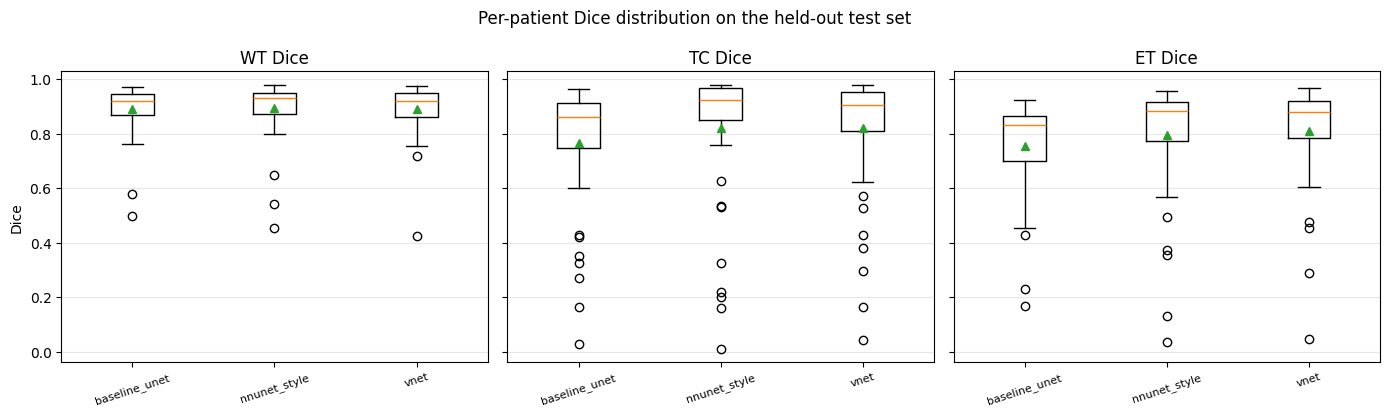

nnunet_style — per-patient spread:


  WT: median 0.930   IQR [0.872, 0.950]   min 0.452   below 0.5: 1/45 patients
  TC: median 0.923   IQR [0.850, 0.966]   min 0.011   below 0.5: 5/45 patients
  ET: median 0.884   IQR [0.772, 0.916]   min 0.036   below 0.5: 5/45 patients


In [4]:
configs = list(per_case["config"].unique())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, region in zip(axes, ["WT", "TC", "ET"]):
    data = [per_case[per_case["config"] == c][f"{region}_dice"].values for c in configs]
    ax.boxplot(data, tick_labels=configs, showmeans=True)
    ax.set_title(f"{region} Dice")
    ax.grid(alpha=0.3, axis="y")
    ax.tick_params(axis="x", rotation=18, labelsize=8)
axes[0].set_ylabel("Dice")
fig.suptitle("Per-patient Dice distribution on the held-out test set")
fig.tight_layout()
plt.show()

best_cfg = max(summary, key=lambda c: summary[c]["metrics"]["WT"]["dice_mean"])
sub = per_case[per_case["config"] == best_cfg]
print(f"{best_cfg} — per-patient spread:")
for region in ["WT", "TC", "ET"]:
    v = sub[f"{region}_dice"]
    print(f"  {region}: median {v.median():.3f}   IQR [{v.quantile(.25):.3f}, {v.quantile(.75):.3f}]"
          f"   min {v.min():.3f}   below 0.5: {(v < 0.5).sum()}/{len(v)} patients")

---
## Step 5 — Did training converge?

Validation Dice is computed on full volumes with sliding-window inference, not on patches —
patch-level scores read far too high because the foreground-biased sampler feeds the model
easier-than-average crops.

The relevant question is whether the curves had flattened. If validation Dice was still
climbing at the final iteration, the binding constraint was the compute budget, not the
method — which changes how the results should be read.

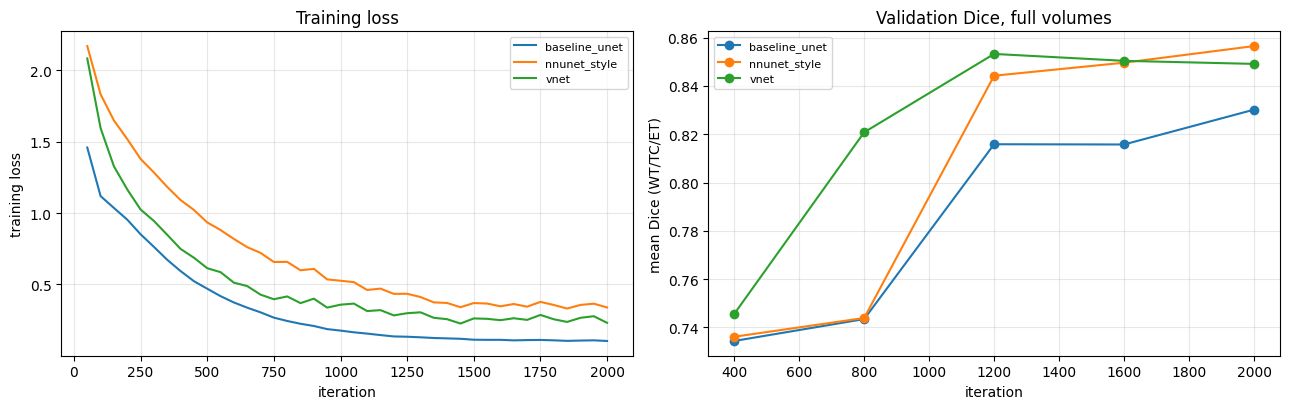

Note: training losses are NOT comparable across configs - baseline_unet uses plain
cross-entropy while the others use Dice+CE. Only validation Dice is comparable.

baseline_unet    final 0.8302   best 0.8302   last improvement at iter 2000/2000
nnunet_style     final 0.8565   best 0.8565   last improvement at iter 2000/2000
vnet             final 0.8491   best 0.8533   last improvement at iter 1200/2000


In [5]:
histories = {}
for f in sorted(LOG_DIR.glob("*_history.json")):
    h = json.loads(f.read_text())
    histories[h["config"]] = h

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
for name, h in histories.items():
    ax1.plot([p["iter"] for p in h["loss_curve"]], [p["loss"] for p in h["loss_curve"]], label=name)
    ax2.plot([p["iter"] for p in h["val_curve"]], [p["mean"] for p in h["val_curve"]],
             marker="o", label=name)
ax1.set(xlabel="iteration", ylabel="training loss", title="Training loss")
ax2.set(xlabel="iteration", ylabel="mean Dice (WT/TC/ET)", title="Validation Dice, full volumes")
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print("Note: training losses are NOT comparable across configs - baseline_unet uses plain")
print("cross-entropy while the others use Dice+CE. Only validation Dice is comparable.\n")
for name, h in histories.items():
    curve = h["val_curve"]
    print(f"{name:<16} final {curve[-1]['mean']:.4f}   best {h['best_val_mean_dice']:.4f}   "
          f"last improvement at iter {max(c['iter'] for c in curve if c['mean'] == h['best_val_mean_dice'])}"
          f"/{h['hyperparameters']['iterations']}")

---
## Step 6 — Where the best model fails

The worst cases are more informative than the best ones. A model that is only ever shown
succeeding is not evidence of anything.

Below are the lowest-scoring test patients, followed by the qualitative panels written by
`scripts/make_figures.py`.

In [6]:
worst = (per_case[per_case["config"] == best_cfg]
         .sort_values("WT_dice")
         .head(5)[["case_id", "WT_dice", "TC_dice", "ET_dice"]])
print(f"{best_cfg} — five worst test patients by whole-tumour Dice:")
display(worst.round(3).set_index("case_id"))

et = per_case[per_case["config"] == best_cfg]["ET_dice"]
print(f"Enhancing tumour is bimodal rather than uniformly mediocre:")
print(f"  patients scoring > 0.8 : {(et > 0.8).sum()}/{len(et)}")
print(f"  patients scoring < 0.5 : {(et < 0.5).sum()}/{len(et)}")
print(f"  patients in between    : {((et >= 0.5) & (et <= 0.8)).sum()}/{len(et)}")
print(f"\nThe mean of {et.mean():.3f} describes neither group.")

print("\nQualitative figures (worst / median / best per config):")
for p in sorted((RESULTS_DIR / "figures").glob("qualitative_*.png")):
    print(f"  results/figures/{p.name}")

nnunet_style — five worst test patients by whole-tumour Dice:


,WT_dice,TC_dice,ET_dice
case_id,,,
BraTS2021_01482,0.452,0.158,0.132
BraTS2021_01459,0.543,0.852,0.895
BraTS2021_01094,0.649,0.219,0.373
BraTS2021_01230,0.799,0.846,0.634
BraTS2021_01536,0.814,0.534,0.667


Enhancing tumour is bimodal rather than uniformly mediocre:
  patients scoring > 0.8 : 32/45
  patients scoring < 0.5 : 5/45
  patients in between    : 8/45

The mean of 0.793 describes neither group.

Qualitative figures (worst / median / best per config):
  results/figures/qualitative_baseline_unet.png
  results/figures/qualitative_nnunet_style.png
  results/figures/qualitative_vnet.png


**Observed failure modes**, from the figures above rather than from speculation:

**Contralateral false positives.** The worst case is not a missed tumour — the real lesion is
segmented reasonably. The model additionally invents a second lesion in the opposite
hemisphere. FLAIR hyperintensity from non-tumour causes (small-vessel disease, gliosis,
normal periventricular signal) looks locally similar to oedema, and a `128³` patch does not
always contain enough context to distinguish them. A whole-brain consistency constraint, or
more training data, is where to attack this.

**Boundary precision lags overlap.** HD95 of 10–13 voxels is high relative to published BraTS
results (~5–8). Dice rewards getting the bulk of a region right; HD95 punishes the worst
boundary excursion. The gap between the two is where the short training budget shows most
clearly.

---

## Summary

| | |
|---|---|
| Best model | `nnunet_style` — Dice 0.893 / 0.821 / 0.793 (WT/TC/ET) |
| Test set | 45 held-out patients, never seen in training or selection |
| Training cost | ~8 minutes per configuration, 25 minutes total |
| Main finding | The configuration bundle helps the hard sub-regions (+0.04–0.05) and not whole tumour |
| Main limitation | One seed per config, 300 of 1,251 patients, no external validation |